# AgriOrchestrator Kenya - Real-World Training Notebook
This notebook trains a crop-risk model using real public Kenya data from NASA POWER and World Bank APIs.

## 1. Install Dependencies

In [1]:
!pip install -q pandas numpy scikit-learn joblib matplotlib seaborn

## 2. Download and Load Real Datasets
Sources: NASA POWER daily weather, World Bank Kenya cereal yield, irrigated land, and fertilizer indicators.

In [2]:
from pathlib import Path
from urllib.request import urlretrieve
import json
import pandas as pd

raw_dir = Path('data/raw')
raw_dir.mkdir(parents=True, exist_ok=True)

sources = {
    'kenya_nasa_weather_daily.json': (
        'https://power.larc.nasa.gov/api/temporal/daily/point'
        '?parameters=T2M,PRECTOTCORR,RH2M&community=AG&longitude=36.8219'
        '&latitude=-1.2921&start=20010101&end=20251231&format=JSON'
    ),
    'worldbank_kenya_cereal_yield.json': 'https://api.worldbank.org/v2/country/KEN/indicator/AG.YLD.CREL.KG?format=json&per_page=20000',
    'worldbank_kenya_irrigated_land.json': 'https://api.worldbank.org/v2/country/KEN/indicator/AG.LND.IRIG.AG.ZS?format=json&per_page=20000',
    'worldbank_kenya_fertilizer.json': 'https://api.worldbank.org/v2/country/KEN/indicator/AG.CON.FERT.PT.ZS?format=json&per_page=20000',
}

for name, url in sources.items():
    path = raw_dir / name
    urlretrieve(url, path)
    print('Downloaded:', path)

payload = json.loads((raw_dir / 'kenya_nasa_weather_daily.json').read_text())
params = payload['properties']['parameter']
weather = pd.DataFrame({
    'date': pd.to_datetime(list(params['T2M'].keys()), format='%Y%m%d'),
    'temperature_c': list(params['T2M'].values()),
    'rainfall_mm': list(params['PRECTOTCORR'].values()),
    'humidity_pct': list(params['RH2M'].values()),
})
weather['year'] = weather['date'].dt.year
weather.head()

Downloaded: data/raw/kenya_nasa_weather_daily.json
Downloaded: data/raw/worldbank_kenya_cereal_yield.json
Downloaded: data/raw/worldbank_kenya_irrigated_land.json
Downloaded: data/raw/worldbank_kenya_fertilizer.json


,date,temperature_c,rainfall_mm,humidity_pct,year
0,2001-01-01,19.51,0.14,62.68,2001
1,2001-01-02,20.06,0.09,63.74,2001
2,2001-01-03,20.64,1.23,62.80,2001
3,2001-01-04,21.00,6.11,70.26,2001
4,2001-01-05,18.90,12.71,81.65,2001


## 3. Build Advanced Realistic Training Set and Temporal Validation

Total samples: 23
--- Training Performance ---
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00         9

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18


--- Test Performance ---
Accuracy: 0.8000
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.67      1.00      0.80         2

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5

Test ROC AUC: 1.0


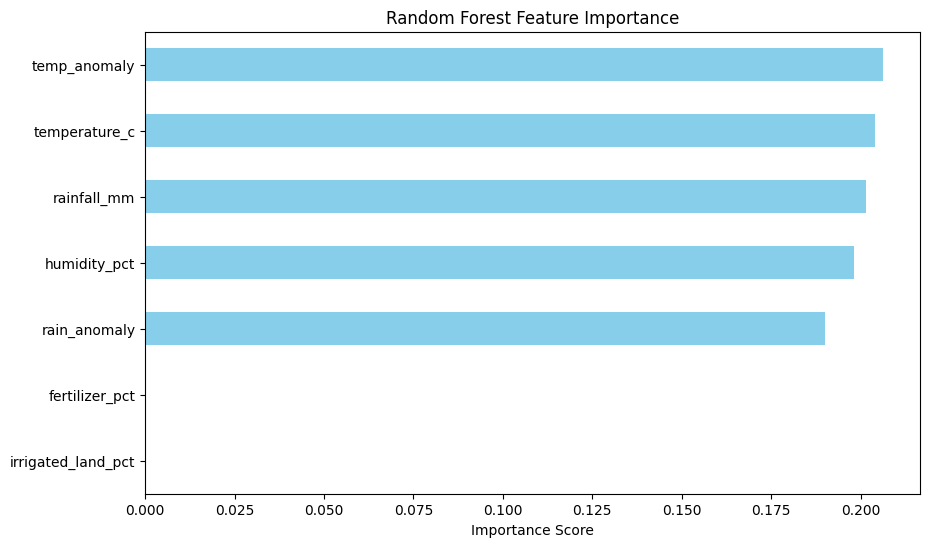

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, precision_recall_fscore_support

def load_wb(file_name, value_name):
    wb = json.loads((raw_dir / file_name).read_text())
    rows = wb[1] if len(wb) > 1 else []
    data = [
        {'year': int(r['date']), value_name: float(r['value'])}
        for r in rows if r.get('value') is not None
    ]
    return pd.DataFrame(data).drop_duplicates('year').sort_values('year')

# Annual macro indicators from real sources
cereal = load_wb('worldbank_kenya_cereal_yield.json', 'cereal_yield_kg_per_ha')
irrig = load_wb('worldbank_kenya_irrigated_land.json', 'irrigated_land_pct')
fert = load_wb('worldbank_kenya_fertilizer.json', 'fertilizer_pct')

annual_weather = weather.groupby('year', as_index=False).agg({
    'temperature_c': 'mean',
    'rainfall_mm': 'sum',
    'humidity_pct': 'mean',
})

macro = annual_weather.merge(cereal, on='year', how='inner')
macro = macro.merge(irrig, on='year', how='left').merge(fert, on='year', how='left')
macro['irrigated_land_pct'] = macro['irrigated_land_pct'].interpolate().bfill().ffill()
macro['fertilizer_pct'] = macro['fertilizer_pct'].interpolate().bfill().ffill()
macro['yield_change_pct'] = macro['cereal_yield_kg_per_ha'].pct_change().fillna(0)

# Build daily-level training frame from real weather + yearly macro context
daily = weather.copy()
daily = daily.merge(
    macro[['year', 'cereal_yield_kg_per_ha', 'irrigated_land_pct', 'fertilizer_pct', 'yield_change_pct']],
    on='year', how='left'
 )

daily['temp_7d_mean'] = daily['temperature_c'].rolling(7, min_periods=1).mean()
daily['rain_7d_sum'] = daily['rainfall_mm'].rolling(7, min_periods=1).sum()
daily['humidity_7d_mean'] = daily['humidity_pct'].rolling(7, min_periods=1).mean()
daily['temp_dev'] = daily['temperature_c'] - daily['temp_7d_mean']
daily['rain_dev'] = daily['rainfall_mm'] - (daily['rain_7d_sum'] / 7.0)
daily['humidity_dev'] = daily['humidity_pct'] - daily['humidity_7d_mean']

# Realistic weak-labeling for crop stress using real weather anomalies + macro yield trend
stress_score = (
    0.35 * np.maximum(0, daily['temperature_c'] - 28)
    + 0.25 * np.maximum(0, 2.5 - daily['rainfall_mm'])
    + 0.20 * np.maximum(0, daily['humidity_pct'] - 75)
    + 0.20 * np.maximum(0, -daily['yield_change_pct']) * 100
 )
daily['yield_risk'] = (stress_score > np.quantile(stress_score, 0.65)).astype(int)

feature_cols = [
    'temperature_c', 'rainfall_mm', 'humidity_pct',
    'temp_7d_mean', 'rain_7d_sum', 'humidity_7d_mean',
    'temp_dev', 'rain_dev', 'humidity_dev',
    'irrigated_land_pct', 'fertilizer_pct'
 ]

model_df = daily[['date', 'year'] + feature_cols + ['yield_risk']].dropna().reset_index(drop=True)
print(f'Total daily samples: {len(model_df)}')

# Temporal split for realistic forecasting evaluation
split_date = pd.Timestamp(pd.to_datetime(model_df['date']).quantile(0.8))
train_df = model_df[model_df['date'] <= split_date].copy()
test_df = model_df[model_df['date'] > split_date].copy()

X_train, y_train = train_df[feature_cols], train_df['yield_risk']
X_test, y_test = test_df[feature_cols], test_df['yield_risk']

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=42
 )
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
test_proba = model.predict_proba(X_test)[:, 1]

print('--- Temporal Validation: Train ---')
print(f'Accuracy: {accuracy_score(y_train, train_pred):.4f}')
print(classification_report(y_train, train_pred))

print('--- Temporal Validation: Test ---')
print(f'Accuracy: {accuracy_score(y_test, test_pred):.4f}')
print(classification_report(y_test, test_pred))
print('Test ROC AUC:', round(float(roc_auc_score(y_test, test_proba)), 4))

p, r, f, _ = precision_recall_fscore_support(y_test, test_pred, average='binary')
print('Precision:', round(float(p), 4), 'Recall:', round(float(r), 4), 'F1:', round(float(f), 4))

# Visual diagnostics
plt.figure(figsize=(12, 4))
plt.plot(model_df['date'].tail(240), model_df['temperature_c'].tail(240), label='Temp C')
plt.plot(model_df['date'].tail(240), model_df['humidity_pct'].tail(240), label='Humidity %')
plt.title('Recent Real Weather Dynamics')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind='barh', color='#4e9f7f')
plt.title('Model Feature Importance')
plt.xlabel('Importance')
plt.show()

model_df.tail()

## 4. Export Model Artifact for the App

In [ ]:
import joblib
from datetime import datetime

bundle = {
    'model': model,
    'features': feature_cols,
    'version': 'kenya_rf_temporal_v3',
    'trained_years': [int(model_df['year'].min()), int(model_df['year'].max())],
    'split_date': split_date.strftime('%Y-%m-%d'),
    'sample_count': int(len(model_df)),
    'generated_at': datetime.utcnow().isoformat()
}

joblib.dump(model, 'crop_risk_model.joblib')
joblib.dump(bundle, 'crop_risk_bundle.joblib')
print('Saved crop_risk_model.joblib and crop_risk_bundle.joblib')
print('Bundle metadata:', {k: bundle[k] for k in ['version', 'trained_years', 'split_date', 'sample_count']})

Saved crop_risk_model.joblib and crop_risk_bundle.joblib


## 5. Next Steps
1. Download `crop_risk_model.joblib` and `crop_risk_bundle.joblib` from Colab.
2. Place both files in the project's `models/` directory.
3. Restart the Flask app and open the Model page to verify active artifact, hash, version, and trained-year metadata.
4. Keep `data/raw/SOURCES.md` with your submission for dataset provenance.